check the fraction NEE / FF

In [1]:
import constants
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
constants.FF_MONTHLY_MEAN = ''

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (226516623.py, line 1)

In [ ]:
ff_df = pd.read_csv(constants.FF_MONTHLY_MEAN)
nee_df = pd.read_csv(constants.NEE_MSA_MONTHLY_MEAN)


In [14]:
# Filter FF data (discard rows outside the 200101 to 201512 range)
ff_df_filtered = ff_df[(ff_df['year'] >= 2001) & (ff_df['year'] <= 2015)]

# Create the 'month' column in the desired format 'YYYYMM'
ff_df_filtered['month'] = ff_df_filtered['year'].astype(int).astype(str) + ff_df_filtered['month'].astype(int).astype(str).str.zfill(2)

# Pivot the FF dataframe to have columns as 'YYYYMM' (e.g., 200101, 200102)
ff_pivot = ff_df_filtered.pivot_table(index='NAMELSAD', columns='month', values='mean', aggfunc='sum')
ff_pivot

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_32008\2335030012.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ff_df_filtered['month'] = ff_df_filtered['year'].astype(int).astype(str) + ff_df_filtered['month'].astype(int).astype(str).str.zfill(2)


month,200101,200102,200103,200104,200105,200106,200107,200108,200109,200110,...,201503,201504,201505,201506,201507,201508,201509,201510,201511,201512
NAMELSAD,,,,,,,,,,,,,,,,,,,,,
"Abilene, TX Metro Area",5.404375,4.705600,4.943114,4.415799,4.473251,4.478902,4.815308,4.952082,4.375163,4.552556,...,4.284977,3.894090,3.917969,3.977311,4.225131,4.288330,3.939648,4.044092,4.084194,4.583883
"Akron, OH Metro Area",50.176360,43.688635,45.893836,40.998020,41.531427,41.583887,44.707223,45.977068,40.620738,42.267719,...,43.528911,39.558083,39.800661,40.403489,42.920971,43.562971,40.020884,41.081875,41.489259,46.565342
"Albany, GA Metro Area",8.820926,7.680196,8.067533,7.206452,7.300086,7.309514,7.858781,8.082178,7.140078,7.429619,...,7.286883,6.621795,6.662241,6.763436,7.185026,7.292590,6.699333,6.876900,6.945349,7.795615
"Albany, OR Metro Area",2.707372,2.357314,2.476299,2.212136,2.240917,2.243748,2.412274,2.480791,2.191779,2.280646,...,1.538609,1.398253,1.406828,1.428136,1.517121,1.539813,1.414612,1.452115,1.466514,1.645937
"Albany-Schenectady-Troy, NY Metro Area",22.786406,19.838135,20.836264,18.608871,18.849755,18.875659,20.295921,20.874179,18.437069,19.185042,...,15.357661,13.953113,14.037077,14.252564,15.142323,15.369729,14.117040,14.490897,14.637155,16.433201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Yakima, WA Metro Area",3.825860,3.331184,3.499325,3.126029,3.166700,3.170700,3.408849,3.505674,3.097263,3.222842,...,2.589893,2.353636,2.368069,2.403936,2.553721,2.591920,2.381171,2.444299,2.468537,2.770555
"York-Hanover, PA Metro Area",120.683917,105.040006,110.279432,98.424351,99.680895,99.847716,107.396546,110.481684,97.507739,101.469747,...,98.779971,89.699022,90.217833,91.640542,97.383806,98.858211,90.761863,93.160224,94.134071,105.753331
"Youngstown-Warren, OH Metro Area",38.753609,33.741220,35.441742,31.657221,32.068113,32.110289,34.524091,35.506124,31.365452,32.637525,...,32.776383,29.783569,29.964929,30.421085,32.317941,32.802074,30.132564,30.931088,31.239857,35.066148


SOME MSA (e.g. northwest Mount Vernon-Anacortes, WA Metro Area has small urban area and most percentage emission is 0)

In [15]:
nee_df.rename(columns=lambda col: col.replace('nee_mean_', '') if col != 'NAMELSAD' else col, inplace=True)

In [16]:
nee_df

,NAMELSAD,200101,200102,200103,200104,200105,200106,200107,200108,200109,...,201503,201504,201505,201506,201507,201508,201509,201510,201511,201512
0,"Sioux Falls, SD-MN Metro Area",0.196938,0.165794,0.336959,0.803317,0.908529,0.005747,-2.841552,-2.162536,0.460029,...,0.546676,0.916681,0.923087,-0.524932,-4.111958,-2.425736,0.510565,0.898531,0.499460,0.246163
1,"Wichita Falls, TX Metro Area",0.039236,-0.095023,-0.329461,-1.127869,-0.579934,-0.121026,0.117073,0.234175,0.150717,...,-0.380534,-1.163378,-0.802617,-0.693899,-0.662105,-0.206197,0.124502,0.225531,0.109438,0.085882
2,"College Station-Bryan, TX Metro Area",0.081037,0.056323,-0.402680,-0.835971,-1.181810,-0.898453,-1.104605,-0.280526,-0.600064,...,-0.022564,-0.942450,-0.768140,-1.270416,-1.015199,-0.135981,0.243083,0.376092,0.095403,0.115941
3,"Grand Forks, ND-MN Metro Area",0.086549,0.065804,0.160914,0.474690,0.433795,-1.002750,-2.751204,-0.625679,0.499341,...,0.272592,0.632968,0.478454,-1.428197,-2.637510,-0.551793,0.689062,0.627717,0.376015,0.151262
4,"Sebring, FL Metro Area",-0.027864,0.060014,-0.160295,-0.453898,-0.615979,-1.115368,-1.048657,-1.476249,-0.905531,...,-0.350672,-0.949286,-1.055155,-1.107771,-1.057074,-1.168895,-0.784255,-0.496974,-0.256004,-0.102280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
378,"Baltimore-Columbia-Towson, MD Metro Area",0.463922,0.355070,0.350825,-0.341685,-1.521426,-2.340371,-2.573700,-1.838521,-0.894595,...,0.410412,-0.149720,-1.812146,-1.858476,-2.457379,-2.028286,-0.543352,0.235405,0.546823,0.525682
379,"Wausau, WI Metro Area",0.306864,0.247596,0.379391,0.576266,-1.144960,-1.693767,-2.487171,-1.811274,0.109337,...,0.418352,0.628587,-0.754591,-2.197036,-2.922208,-0.842889,-0.241514,0.855052,0.653901,0.421606
380,"Wichita, KS Metro Area",0.114795,0.111726,0.069614,-0.577163,-0.976278,-0.605948,-0.347088,0.134643,0.108414,...,-0.042978,-0.413870,-0.657561,-0.423870,-0.726330,-0.857068,-0.051101,0.294564,0.091737,0.081328
381,"Williamsport, PA Metro Area",0.832419,0.783956,0.897872,0.572998,-2.586020,-4.274259,-3.646483,-2.939299,-1.807260,...,0.794016,0.780977,-2.576494,-2.870689,-3.781047,-2.819292,-1.264966,0.713695,1.025101,0.952037


In [17]:
# Align the indices and columns of nee_df and ff_pivot
nee_aligned, ff_aligned = nee_df.set_index('NAMELSAD').align(ff_pivot, join='inner', axis=1)

# Calculate the ratio nee_df / ff_pivot
nee_ff_ratio = nee_aligned / ff_aligned

# Display the result
nee_ff_ratio

,200101,200102,200103,200104,200105,200106,200107,200108,200109,200110,...,201503,201504,201505,201506,201507,201508,201509,201510,201511,201512
NAMELSAD,,,,,,,,,,,,,,,,,,,,,
"Abilene, TX Metro Area",0.016718,-0.003107,-0.035090,-0.155385,-0.058801,0.005605,0.042626,0.051824,-0.012314,-0.008085,...,-0.017746,-0.124217,-0.151760,-0.186025,-0.108475,-0.003228,0.050993,0.048975,0.030537,0.024322
"Akron, OH Metro Area",0.009806,0.008157,0.010231,0.000897,-0.032149,-0.051610,-0.049550,-0.032390,-0.015082,0.011070,...,0.006092,0.010138,-0.035849,-0.043074,-0.048135,-0.027634,-0.007616,0.012572,0.015305,0.012854
"Albany, GA Metro Area",0.024548,0.029510,-0.012409,-0.122406,-0.122473,-0.141822,-0.217633,-0.166858,-0.128291,-0.011543,...,0.006017,-0.052187,-0.201989,-0.222749,-0.279785,-0.229829,-0.065687,0.006039,0.022755,0.037264
"Albany, OR Metro Area",0.057783,-0.098222,-0.276389,-0.561400,-1.463026,-1.240871,-0.905377,-0.759602,-0.668978,-0.206119,...,-0.754786,-1.573959,-1.527535,-2.005949,-1.246362,-1.021946,-0.917264,-0.297573,0.090184,0.205863
"Albany-Schenectady-Troy, NY Metro Area",0.032016,0.033693,0.039369,0.018268,-0.125319,-0.199766,-0.197157,-0.138982,-0.087826,0.027443,...,0.044488,0.041375,-0.188998,-0.239251,-0.252398,-0.212927,-0.093169,0.043611,0.062777,0.055368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Yakima, WA Metro Area",0.054142,0.050343,-0.005803,-0.130230,-0.305325,-0.312546,-0.263194,-0.190272,-0.144279,-0.010090,...,-0.145833,-0.384728,-0.420253,-0.495947,-0.353780,-0.239453,-0.135802,-0.002827,0.072289,0.082078
"York-Hanover, PA Metro Area",0.004147,0.003429,0.003816,-0.001026,-0.013692,-0.021183,-0.019571,-0.013625,-0.006082,0.003349,...,0.004288,0.001033,-0.016933,-0.018755,-0.027420,-0.021818,-0.005560,0.003563,0.006220,0.005282
"Youngstown-Warren, OH Metro Area",0.013148,0.010181,0.013796,0.005752,-0.034282,-0.065087,-0.065933,-0.040344,-0.014651,0.016539,...,0.009385,0.017932,-0.040868,-0.046921,-0.063600,-0.032886,0.000329,0.019941,0.022231,0.017920


C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_32008\2565311006.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


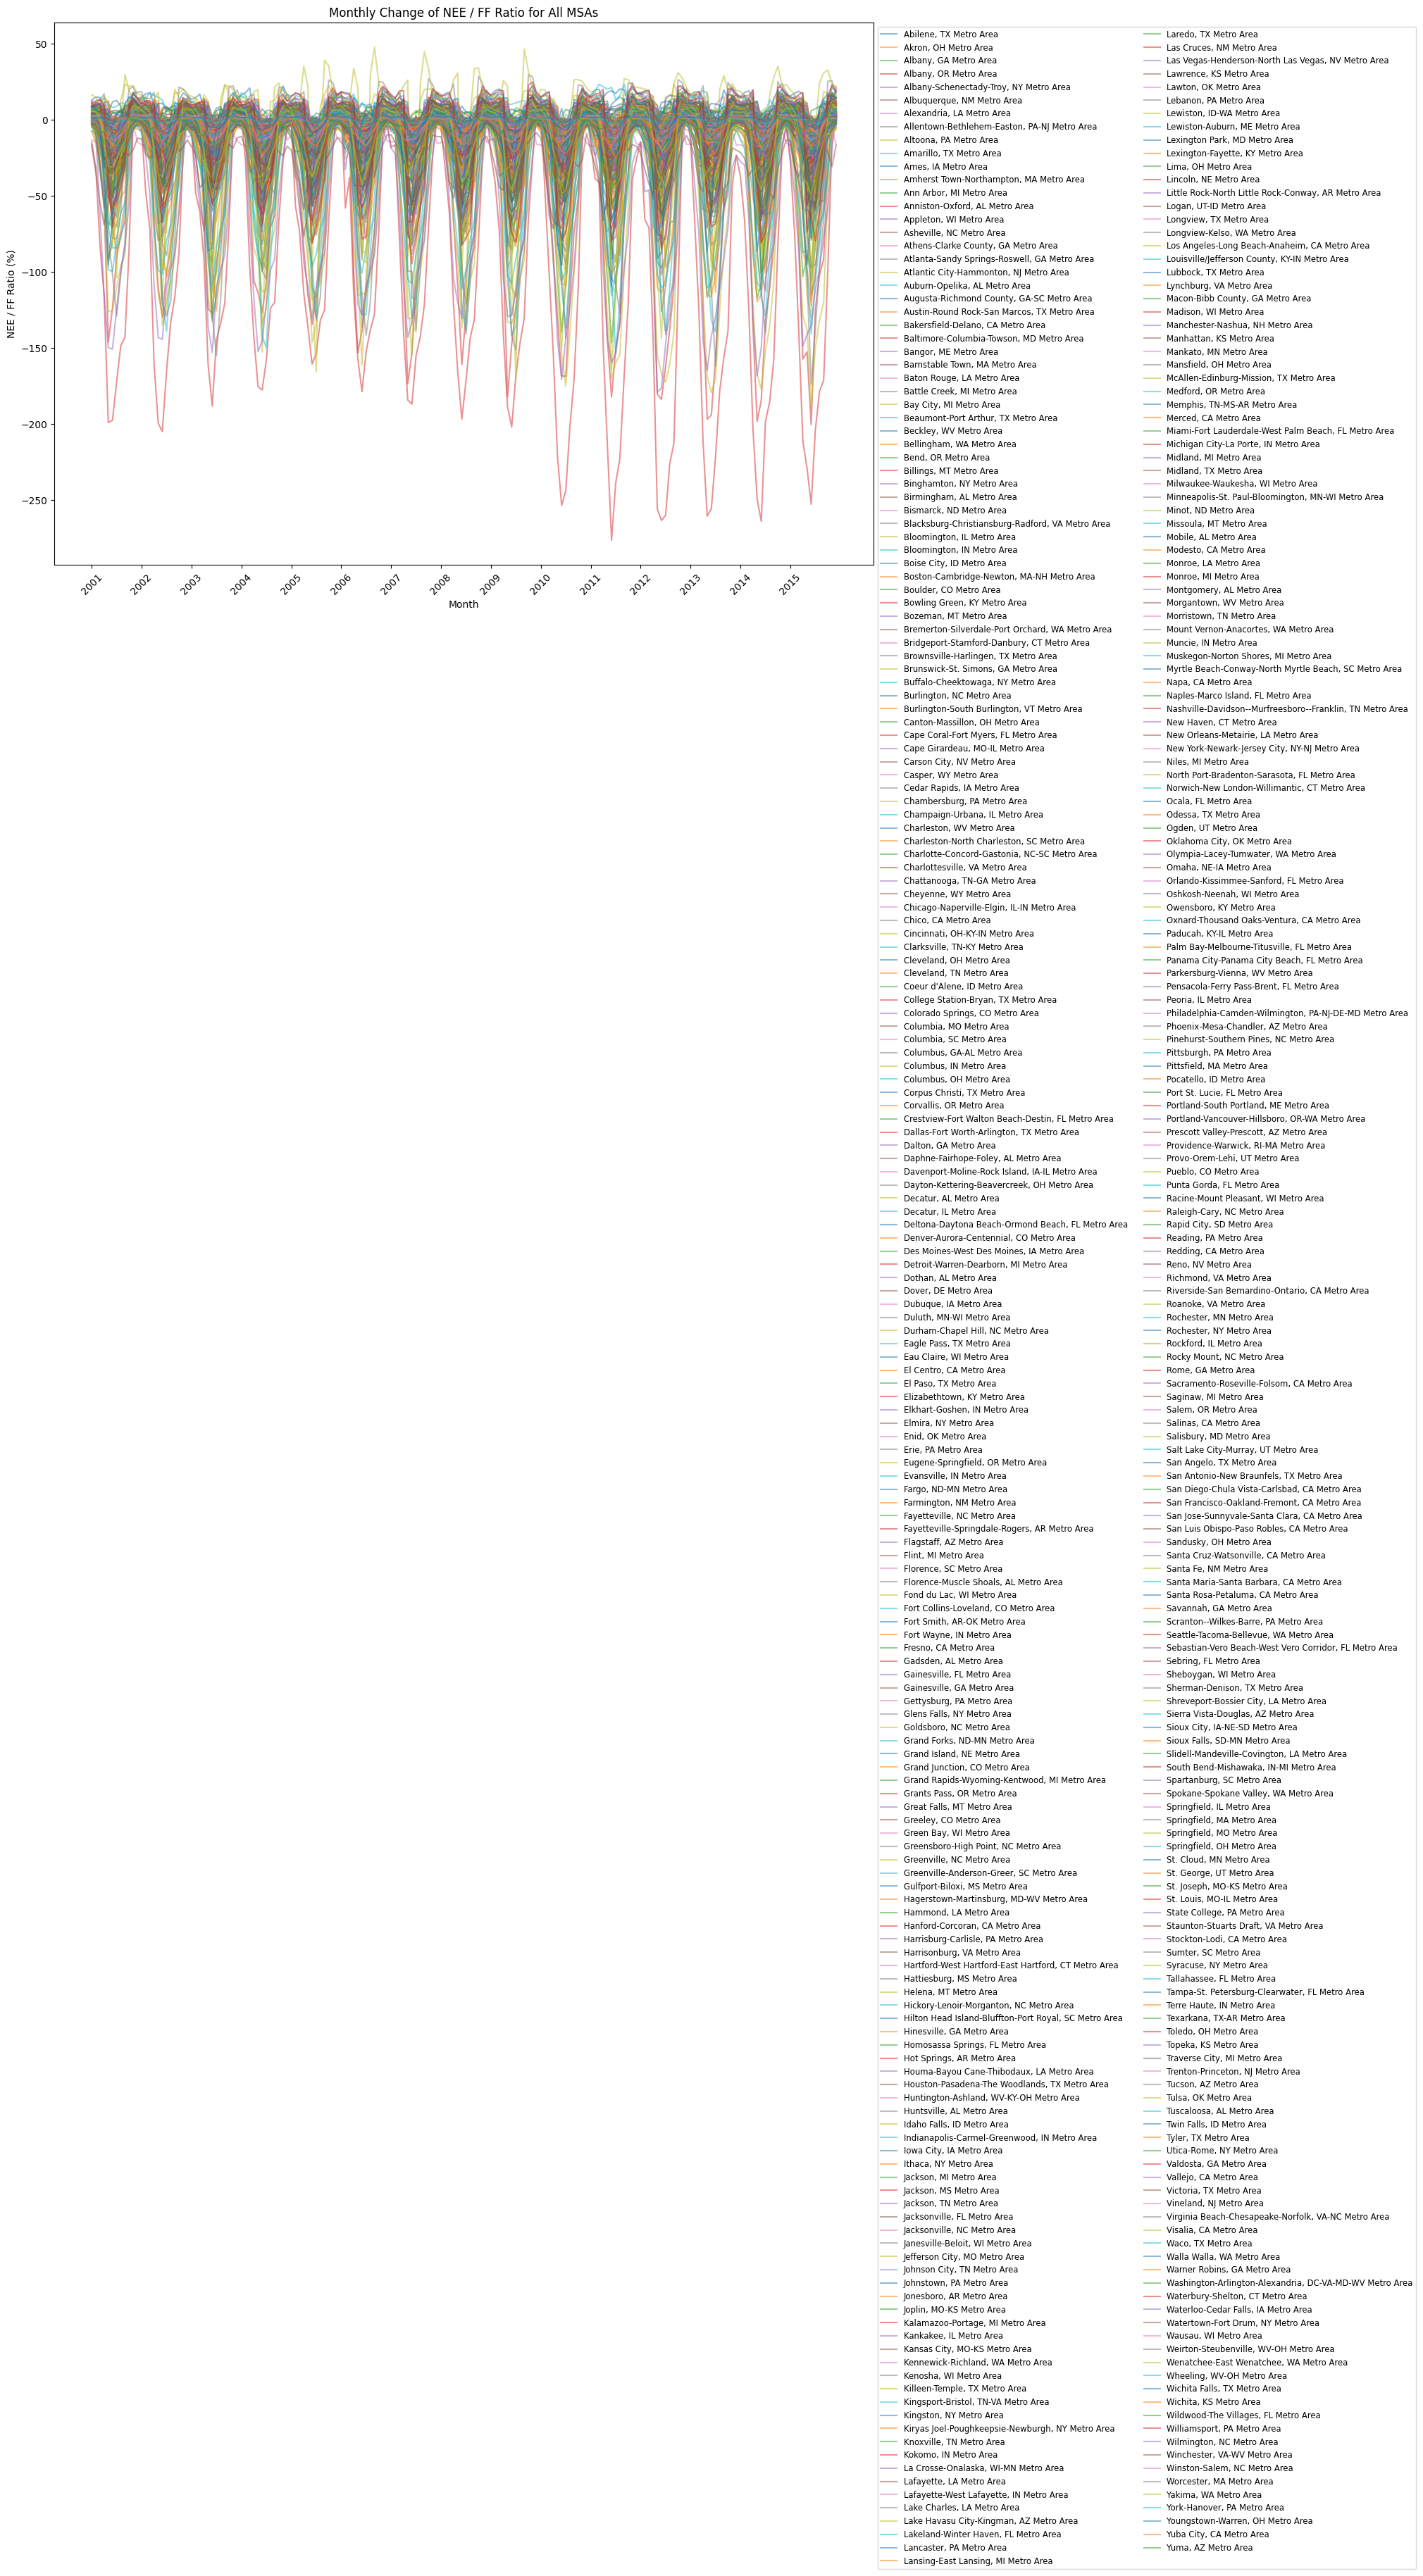

In [ ]:
# Transpose the nee_ff_ratio dataframe for plotting
nee_ff_ratio_transposed = nee_ff_ratio.T
nee_ff_ratio_transposed*= 100 # fraction to percentage
# Plot each MSA as a line
plt.figure(figsize=(15, 10))
for msa in nee_ff_ratio_transposed.columns:
    plt.plot(nee_ff_ratio_transposed.index, nee_ff_ratio_transposed[msa], label=msa, alpha=0.5)

# Add labels and title
plt.xlabel('Month')
plt.ylabel('NEE / FF Ratio (%)')
plt.title('Monthly Change of NEE / FF Ratio for All MSAs')
plt.xticks(rotation=45)
plt.xticks(ticks=nee_ff_ratio_transposed.index[::12], labels=[str(year) for year in range(2001, 2016)])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small', ncol=2)
plt.tight_layout()

# Show the plot
plt.show()

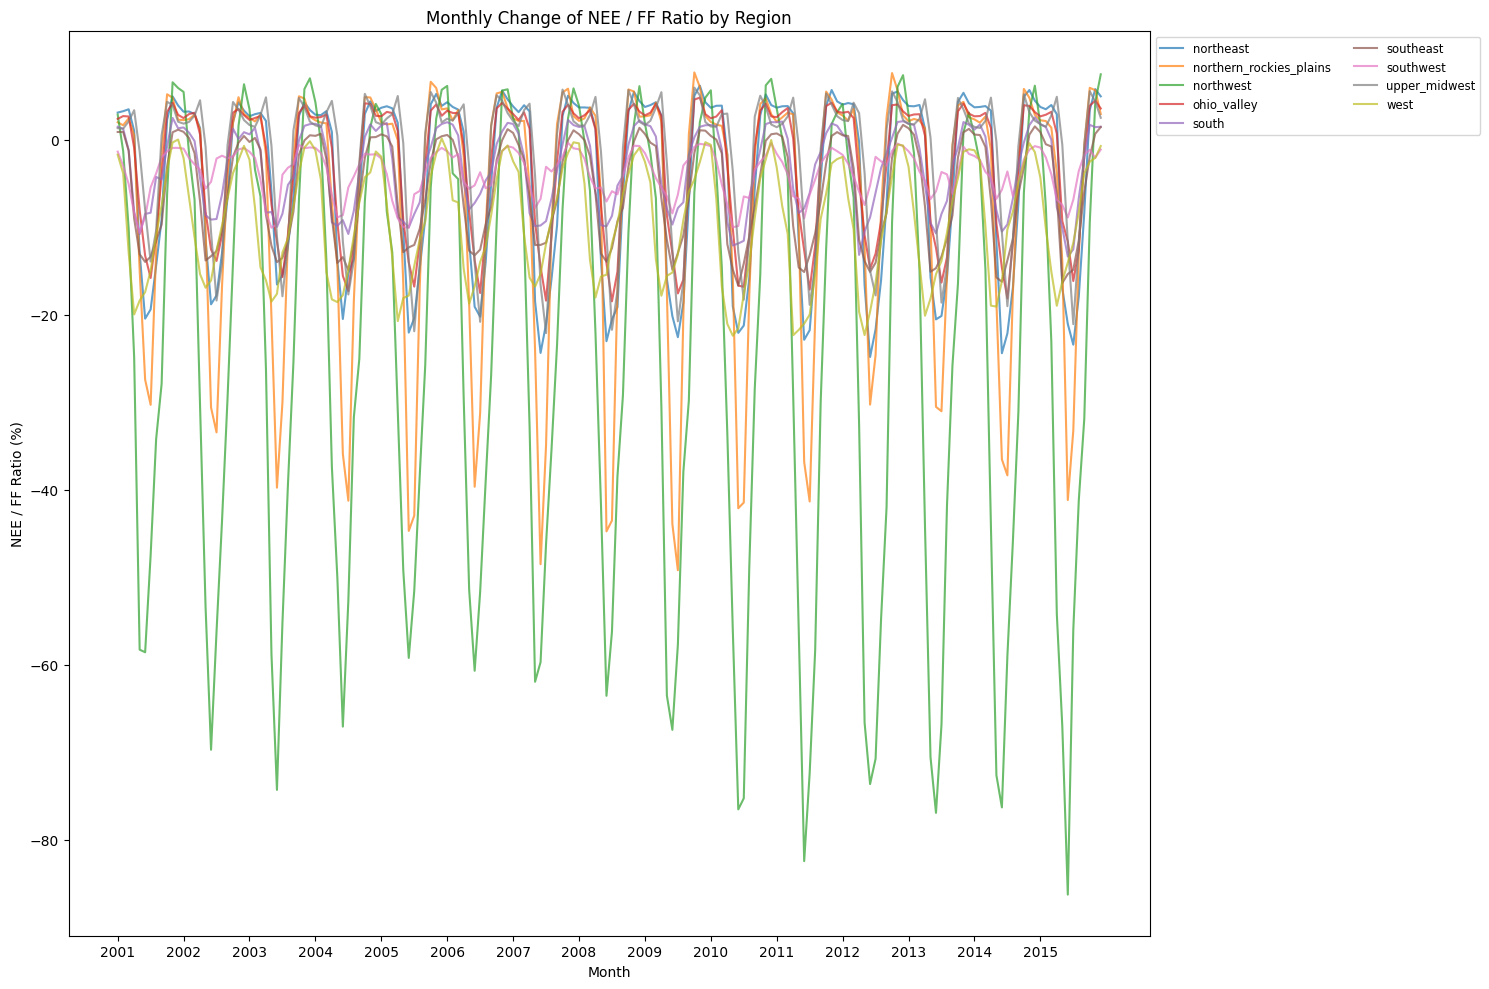

In [ ]:
msa_region_table = pd.read_csv(constants.MSA_NAME_REGION_TABLE)
nee_ff_ratio_with_region = nee_ff_ratio.merge(msa_region_table, on='NAMELSAD')
nee_ff_ratio_with_region.drop(columns=['NAMELSAD'], inplace=True)
region_monthly_mean = nee_ff_ratio_with_region.groupby('region').mean().T
# Convert the y-axis values from fraction to percentage
region_monthly_mean *= 100

# Plot each region as a line
plt.figure(figsize=(15, 10))
for region in region_monthly_mean.columns:
    plt.plot(region_monthly_mean.index, region_monthly_mean[region], label=region, alpha=0.7)

# Add labels and title
plt.xlabel('Month')
plt.ylabel('NEE / FF Ratio (%)')
plt.title('Monthly Change of NEE / FF Ratio by Region')
plt.xticks(ticks=region_monthly_mean.index[::12], labels=[str(year) for year in range(2001, 2016)])
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small', ncol=2)
plt.tight_layout()

# Show the plot
plt.show()

In [6]:
print(ff_df.columns)
print(nee_df.columns)

Index(['system:index', 'NAMELSAD', 'mean', 'month', 'year', '.geo'], dtype='object')
Index(['NAMELSAD', 'nee_mean_200101', 'nee_mean_200102', 'nee_mean_200103',
       'nee_mean_200104', 'nee_mean_200105', 'nee_mean_200106',
       'nee_mean_200107', 'nee_mean_200108', 'nee_mean_200109',
       ...
       'nee_mean_201503', 'nee_mean_201504', 'nee_mean_201505',
       'nee_mean_201506', 'nee_mean_201507', 'nee_mean_201508',
       'nee_mean_201509', 'nee_mean_201510', 'nee_mean_201511',
       'nee_mean_201512'],
      dtype='object', length=181)


In [12]:
# Filter FF data (discard rows outside the 200101 to 201512 range)
ff_df_filtered = ff_df[(ff_df['year'] >= 2001) & (ff_df['year'] <= 2015)]

# Create the 'month' column in the desired format 'YYYYMM' for both FF and NEE datasets
ff_df_filtered['month'] = ff_df_filtered['year'].astype(str) + ff_df_filtered['month'].astype(str).str.zfill(2)

# Pivot the FF dataframe to have columns as 'YYYYMM' (e.g., 200101, 200102)
ff_pivot = ff_df_filtered.pivot_table(index='NAMELSAD', columns='month', values='mean', aggfunc='sum')
ff_pivot

C:\Users\qifanw\AppData\Local\Temp\1\ipykernel_32008\2472837832.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ff_df_filtered['month'] = ff_df_filtered['year'].astype(str) + ff_df_filtered['month'].astype(str).str.zfill(2)


month,2001.01.0,2001.010.0,2001.011.0,2001.012.0,2001.02.0,2001.03.0,2001.04.0,2001.05.0,2001.06.0,2001.07.0,...,2015.011.0,2015.012.0,2015.02.0,2015.03.0,2015.04.0,2015.05.0,2015.06.0,2015.07.0,2015.08.0,2015.09.0
NAMELSAD,,,,,,,,,,,,,,,,,,,,,
"Abilene, TX Metro Area",5.404375,4.552556,4.463946,4.910079,4.705600,4.943114,4.415799,4.473251,4.478902,4.815308,...,4.084194,4.583883,4.218361,4.284977,3.894090,3.917969,3.977311,4.225131,4.288330,3.939648
"Akron, OH Metro Area",50.176360,42.267719,41.445054,45.587116,43.688635,45.893836,40.998020,41.531427,41.583887,44.707223,...,41.489259,46.565342,42.852186,43.528911,39.558083,39.800661,40.403489,42.920971,43.562971,40.020884
"Albany, GA Metro Area",8.820926,7.429619,7.285092,8.013577,7.680196,8.067533,7.206452,7.300086,7.309514,7.858781,...,6.945349,7.795615,7.174091,7.286883,6.621795,6.662241,6.763436,7.185026,7.292590,6.699333
"Albany, OR Metro Area",2.707372,2.280646,2.236256,2.459750,2.357314,2.476299,2.212136,2.240917,2.243748,2.412274,...,1.466514,1.645937,1.514689,1.538609,1.398253,1.406828,1.428136,1.517121,1.539813,1.414612
"Albany-Schenectady-Troy, NY Metro Area",22.786406,19.185042,18.812432,20.696597,19.838135,20.836264,18.608871,18.849755,18.875659,20.295921,...,14.637155,16.433201,15.123840,15.357661,13.953113,14.037077,14.252564,15.142323,15.369729,14.117040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Yakima, WA Metro Area",3.825860,3.222842,3.160113,3.475939,3.331184,3.499325,3.126029,3.166700,3.170700,3.408849,...,2.468537,2.770555,2.549629,2.589893,2.353636,2.368069,2.403936,2.553721,2.591920,2.381171
"York-Hanover, PA Metro Area",120.683917,101.469747,99.510386,109.534250,105.040006,110.279432,98.424351,99.680895,99.847716,107.396546,...,94.134071,105.753331,97.340700,98.779971,89.699022,90.217833,91.640542,97.383806,98.858211,90.761863
"Youngstown-Warren, OH Metro Area",38.753609,32.637525,32.002919,35.204547,33.741220,35.441742,31.657221,32.068113,32.110289,34.524091,...,31.239857,35.066148,32.270777,32.776383,29.783569,29.964929,30.421085,32.317941,32.802074,30.132564


In [ ]:
# Prepare NEE dataframe (melt to long format and group by NAMELSAD and year)
nee_df_long = nee_df.melt(id_vars=['NAMELSAD'], var_name='month', value_name='nee_mean')
nee_df_long['year'] = nee_df_long['month'].str[9:13].astype(int)
nee_df_long['month'] = nee_df_long['month'].str[13:].astype(int)

# nee_long_df['Year'] = nee_long_df['Month'].str[9:13].astype(int)
# nee_long_df['Month'] = nee_long_df['Month'].str[13:15].astype(int)
# nee_long_df['Month_Date'] = pd.to_datetime(nee_long_df['Year'].astype(str) + nee_long_df['Month'].astype(str).str.zfill(2), format='%Y%m')

nee_yearly = nee_df_long.groupby(['NAMELSAD', 'year'])['nee_mean'].mean().reset_index()